# Physical Health

## Overview

This section analyzes physical health and body composition metrics to understand their relationship with heart disease.

The goal is to identify risk factors such as BMI, physical health, and daily functional limitations attribute to the probability of developing cardiovascular issues.

### Questions:

1. How does body composition such as BMI, height, and weight relate to heart disease risk?

2. How does the number of physically unhealthy days impact heart disease rates?

3. How does mobility and functional limitations correlate with heart disease?

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/data/heart_cleaned.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
df.head()

,State,Sex,GeneralHealth,PhysicalHealthDays,MentalHealthDays,LastCheckupTime,PhysicalActivities,SleepHours,RemovedTeeth,HadHeartAttack,...,WeightInKilograms,BMI,AlcoholDrinkers,HIVTesting,FluVaxLast12,PneumoVaxEver,TetanusLast10Tdap,HighRiskLastYear,CovidPos,HadHeartDisease
0,Alabama,Female,Very good,0.0,0.0,Within past year (anytime less than 12 months ...,No,8.0,Unknown,No,...,80.74,27.44,No,No,Yes,No,"Yes, received tetanus shot but not sure what type",No,No,0
1,Alabama,Female,Excellent,0.0,0.0,Unknown,No,6.0,Unknown,No,...,68.04,26.57,No,No,No,No,"No, did not receive any tetanus shot in the pa...",No,No,0
2,Alabama,Female,Very good,2.0,3.0,Within past year (anytime less than 12 months ...,Yes,5.0,Unknown,No,...,63.50,25.61,No,No,No,No,Unknown,No,Yes,0
3,Alabama,Female,Excellent,0.0,0.0,Within past year (anytime less than 12 months ...,Yes,7.0,Unknown,No,...,63.50,23.30,No,No,Yes,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0
4,Alabama,Female,Fair,2.0,0.0,Within past year (anytime less than 12 months ...,Yes,9.0,Unknown,No,...,53.98,21.77,Yes,No,No,Yes,"No, did not receive any tetanus shot in the pa...",No,No,0


## Important Statistics

In [122]:
cols = [
    "HadHeartDisease",
    "BMI",
    "HeightInMeters",
    "WeightInKilograms",
    "PhysicalHealthDays",
    "DifficultyWalking",
    "DifficultyDressingBathing",
    "DifficultyErrands"
]

data = df[cols].copy()

In [37]:
data.describe()

,HadHeartDisease,BMI,HeightInMeters,WeightInKilograms,PhysicalHealthDays
count,438479.000000,438479.000000,438479.000000,438479.000000,438479.000000
mean,0.086935,28.404338,1.702629,82.847856,4.179466
std,0.281740,6.186044,0.103673,20.400436,8.538093
min,0.000000,12.020000,0.910000,22.680000,0.000000
25%,0.000000,24.410000,1.630000,68.040000,0.000000
50%,0.000000,27.440000,1.700000,80.740000,0.000000
75%,0.000000,31.010000,1.780000,91.630000,3.000000
max,1.000000,99.640000,2.410000,292.570000,30.000000


In [90]:
print("Heart Disease Rate:", data["HadHeartDisease"].mean() * 100)
print("Average BMI:", data["BMI"].mean())
print("Average Height:", data["HeightInMeters"].mean())
print("Average Weight:", data["WeightInKilograms"].mean())
print("Average Physical Health Days:", data["PhysicalHealthDays"].mean())

Heart Disease Rate: 8.693460804280251
Average BMI: 28.404338406172243
Average Height: 1.7026287005763117
Average Weight: 82.84785613450131
Average Physical Health Days: 4.179465835307962


## 1. Body Composition

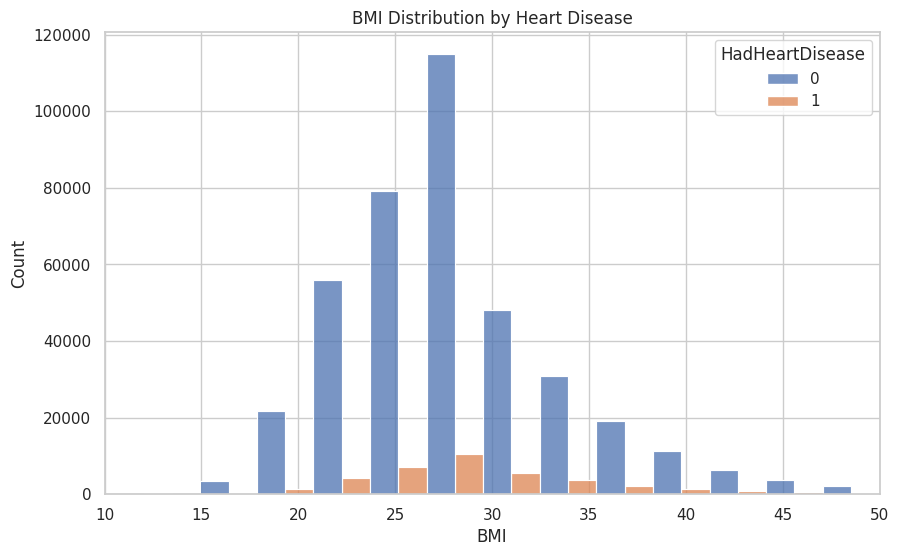

In [60]:
sns.histplot(
    data=data,
    x="BMI",
    hue="HadHeartDisease",
    bins=30,
    multiple="dodge")
plt.xlim(10, 50)
plt.title("BMI Distribution by Heart Disease")
plt.show()

In [98]:
obese = data[data["BMI"] > 30]
not_obese = data[data["BMI"] <= 30]
print("Heart Disease Rate for BMI > 30:", obese["HadHeartDisease"].mean() * 100)
print("Heart Disease Rate for BMI <= 30:", not_obese["HadHeartDisease"].mean() * 100)

Heart Disease Rate for BMI > 30: 10.545971491143812
Heart Disease Rate for BMI <= 30: 7.911618192667929


### Analysis:

The BMI distribution shows that the "no heart disease" and "had heart disease" groups share a similar overall distribution. However, the rate of heart disease does increase with individuals that have higher BMIs.

This could suggest that a higher BMI is associated with an increased likelihood of heart disease.

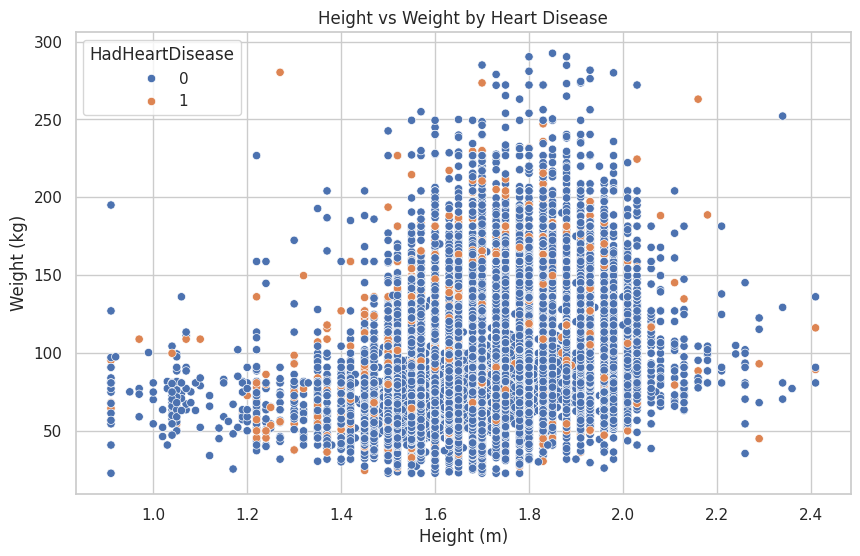

In [85]:
sns.scatterplot(
    data=data,
    x="HeightInMeters",
    y="WeightInKilograms",
    hue="HadHeartDisease"
)

plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight by Heart Disease")
plt.show()

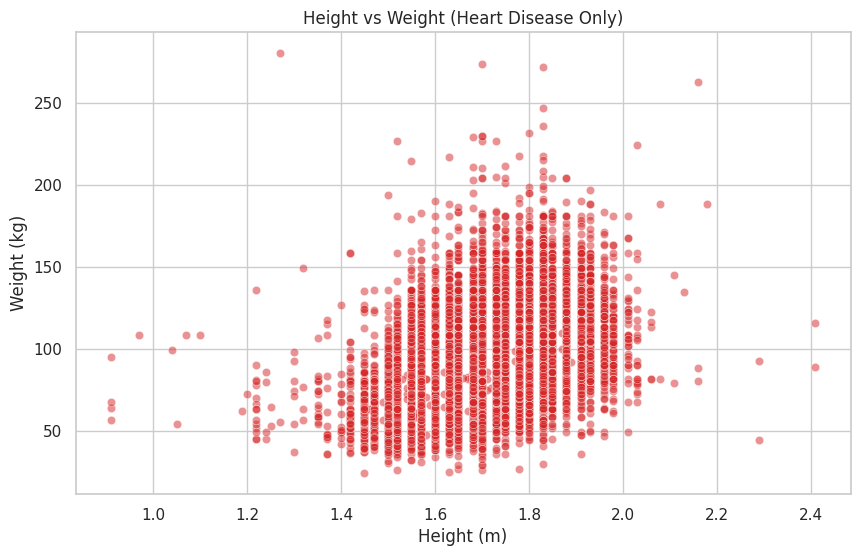

In [99]:
hd = data[data["HadHeartDisease"] == 1]

sns.scatterplot(
    data=hd,
    x="HeightInMeters",
    y="WeightInKilograms",
    color="#d62728",
    alpha=0.5
)

plt.title("Height vs Weight (Heart Disease Only)")
plt.xlabel("Height (m)")
plt.ylabel("Weight (kg)")
plt.show()

In [96]:
hd = data[data["HadHeartDisease"] == 1]
no_hd = data[data["HadHeartDisease"] == 0]

print("Had Heart Disease")
print("Avg Height:", hd["HeightInMeters"].mean())
print("Avg Weight:", hd["WeightInKilograms"].mean(), "\n")
print("No Heart Disease")
print("Avg Height:", no_hd["HeightInMeters"].mean())
print("Avg Weight:", no_hd["WeightInKilograms"].mean())

Had Heart Disease
Avg Height: 1.708198798499436
Avg Weight: 85.94099005745167 

No Heart Disease
Avg Height: 1.7020983614746734
Avg Weight: 82.55335325706864


### Analysis:

When analysing the scatter plot, I noticed that the relationship between height and weight in correlation with heart disease does not differ too much. The way the points are distributed make sense since most likely if a person is taller, they would weigh more as well. However, when I averaged out the height and weight of the two groups was when we can really see the picture.

While height does not prove to be a strong indicator of heart disease, weight does play a more significant roll. As those with heart disease had a higher average weight compared to those without heart disease.

## 2. Physical Health Days

The number of days in the past month that people reported they were "unhealthy."

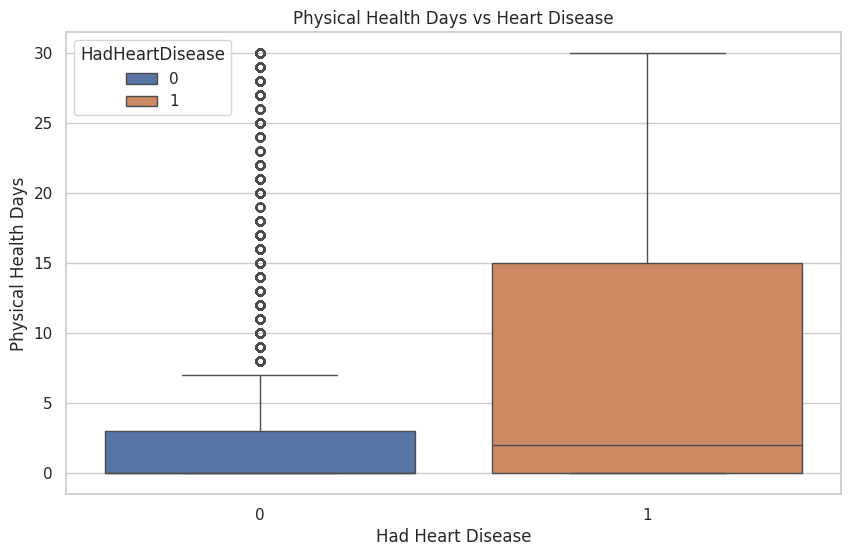

In [105]:
sns.boxplot(
    data=data,
    x="HadHeartDisease",
    y="PhysicalHealthDays",
    hue="HadHeartDisease"
)

plt.title("Physical Health Days vs Heart Disease")
plt.ylabel("Physical Health Days")
plt.xlabel("Had Heart Disease")
plt.show()

In [108]:
hd = data[data["HadHeartDisease"] == 1]["PhysicalHealthDays"].mean()
no_hd = data[data["HadHeartDisease"] == 0]["PhysicalHealthDays"].mean()

print("Avg unhealthy days vs heart disease:", hd)
print("Avg unhealthy days vs no heart disease:", no_hd)

Avg unhealthy days vs heart disease: 8.731629895852462
Avg unhealthy days vs no heart disease: 3.746046058547307


### Analysis:

There is clear evidence that people who report a higher number of physically unhealthy days have had heart disease. It is important to note that this could be because they already have health problems, including cardiovascular. This graph basically just shows that an unhealthy person reported that they felt unhealthy.

That being said, it still shows that poor physical health is associated with a higher rate of heart disease.

## 3. Mobility and Functional Limitations

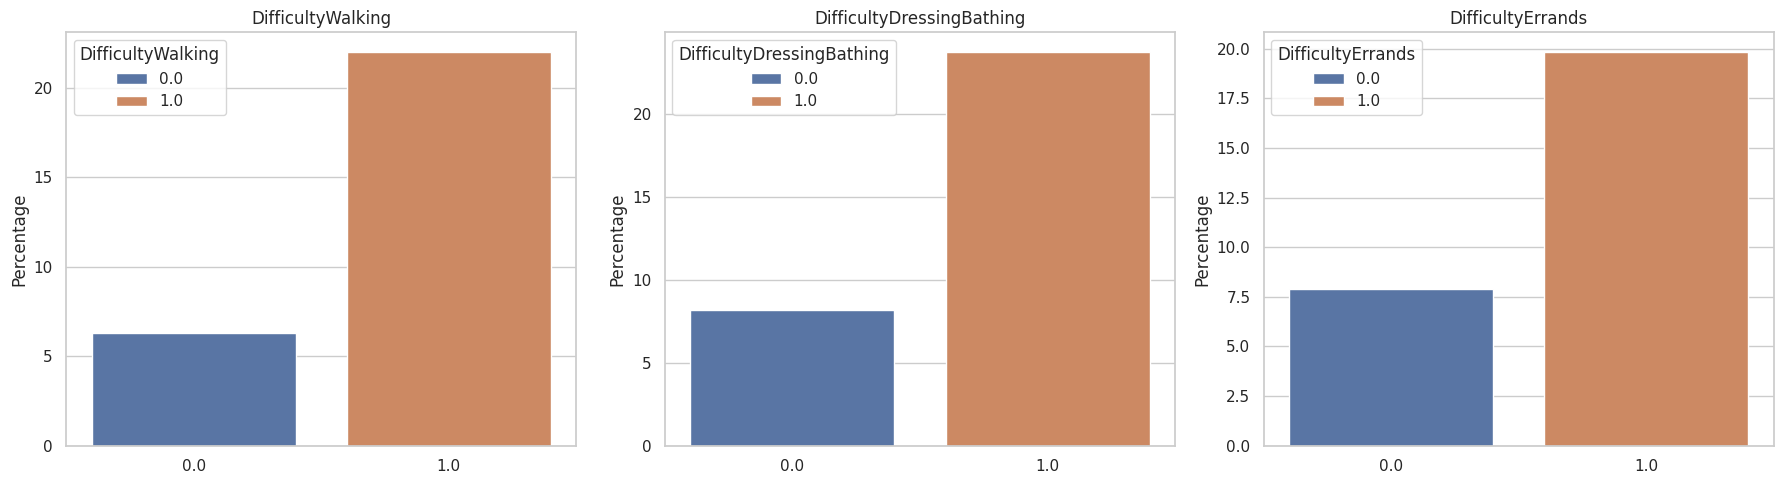

In [115]:
features = [
    "DifficultyWalking",
    "DifficultyDressingBathing",
    "DifficultyErrands"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features):
    rates = data.groupby(col)["HadHeartDisease"].mean() * 100

    sns.barplot(
        x=rates.index,
        y=rates.values,
        hue=rates.index,
        ax=axes[i]
    )

    axes[i].set_title(col)
    axes[i].set_ylabel("Percentage")
    axes[i].set_xlabel("")

plt.tight_layout()
plt.show()

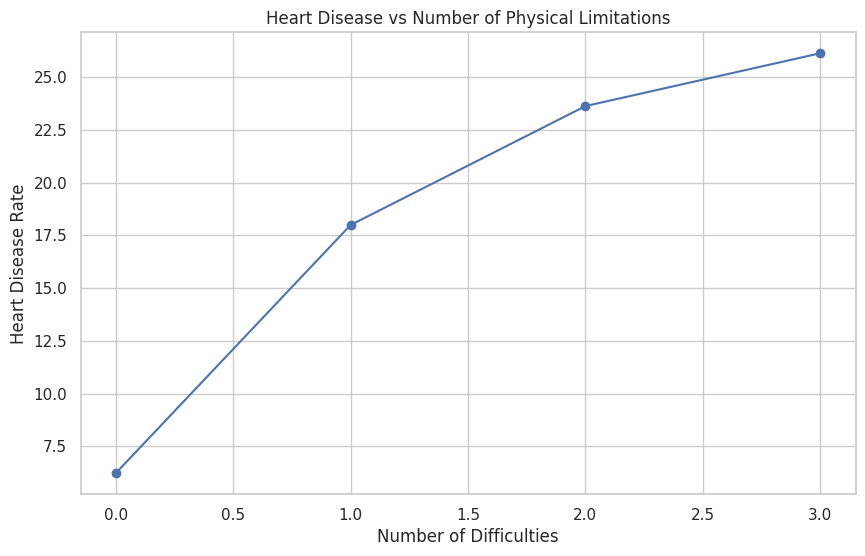

In [123]:
for col in features:
    data[col] = data[col].map({"Yes": 1, "No": 0})

data["DifficultyCount"] = data[features].sum(axis=1)

risk = data.groupby("DifficultyCount")["HadHeartDisease"].mean() * 100

risk.plot(marker="o")
plt.title("Heart Disease vs Number of Physical Limitations")
plt.ylabel("Heart Disease Rate")
plt.xlabel("Number of Difficulties")
plt.show()

### Analysis:

There is a strong indicator for heart disease for people who report difficulty for all 3 limitations. The bar charts show that people who report difficulties in all 3 have significantly higher rates of heart disease. But similar to question 2. It is like saying a unhealthy person is unhealthy.

However, this does show that difficulties performing daily activities do indicate cardivascular risk. As shown in the line graph. It goes to show that having cardiovascular issues could negatively affect your daily life.

## Conclusion

Overall, the biggest takeaway from this survey was that individuals who tend to weigh more or had a higher BMI had a higher rate of heart disease. This study also shows that people who have had heart problems struggle with simple everyday activities more so than those who have never had any problems.

In [52]:
correlations = data.corr(numeric_only=True)["HadHeartDisease"].sort_values(ascending=False)
correlations

,HadHeartDisease
HadHeartDisease,1.000000
DifficultyWalking,0.202838
DifficultyCount,0.188817
PhysicalHealthDays,0.164514
DifficultyErrands,0.111561
DifficultyDressingBathing,0.106153
WeightInKilograms,0.046785
BMI,0.043904
HeightInMeters,0.016578
